<a href="https://colab.research.google.com/github/244110601105-Adinda/FindMe/blob/main/Machine_Learning_Pertemuan5_svm_naivebayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/content/pertemuan5-svm-naivebayes
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/pertemuan5-svm-naivebayes/.git/
[master (root-commit) 02fc017] Initial commit: README
 1 file changed, 1 insertion(+)
 create mode 100644 README.md
Mounted at /content/drive
/content/drive/MyDrive
Cloning into 'pertemuan5-svm-naivebayes'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'pertemuan5-svm-naivebayes'
/content/drive/MyDrive
fatal: not a git reposi

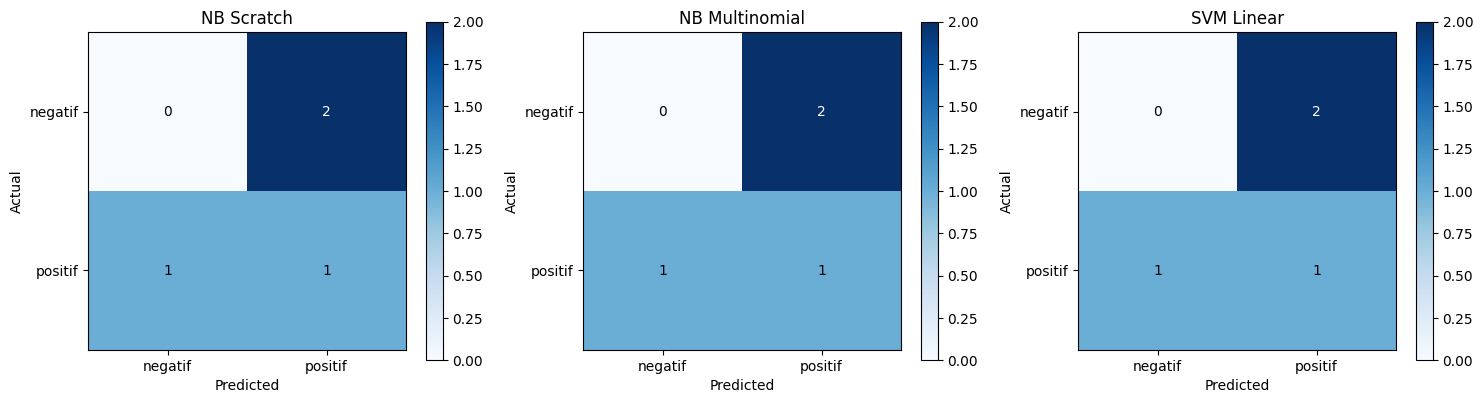

=== CROSS-VALIDATION (5-Fold) ===
NB Multinomial       | F1: 0.7933 ± 0.1890
NB Bernoulli         | F1: 0.7933 ± 0.1890
SVM Linear           | F1: 0.7867 ± 0.1067
SVM RBF              | F1: 0.6933 ± 0.1855
Fitting 5 folds for each of 32 candidates, totalling 160 fits
=== GRIDSEARCH SVM ===
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.7667
Test Accuracy  : 0.2500
Test F1-Score  : 0.4000
=== GRIDSEARCH NAÏVE BAYES ===
Best Alpha: {'alpha': 0.01}
Best CV Score: 0.8667
Test Accuracy: 0.2500
=== PREDIKSI DATA BARU ===

Komentar: 'Alhamdulillah, kajiannya sangat bermanfaat dan menenangkan hati'
  Naïve Bayes: POSITIF
  SVM        : POSITIF

Komentar: 'Saya kecewa, materinya tidak sesuai dan membosankan'
  Naïve Bayes: NEGATIF
  SVM        : NEGATIF

Komentar: 'Penyampaian ustadz sangat jelas dan mudah dipahami'
  Naïve Bayes: POSITIF
  SVM        : POSITIF
=== KATA PALING INDIKATIF POSITIF ===
  saya: -2.3656
  ini: -3.0563
  yang: -3.0563
  penyampaiann

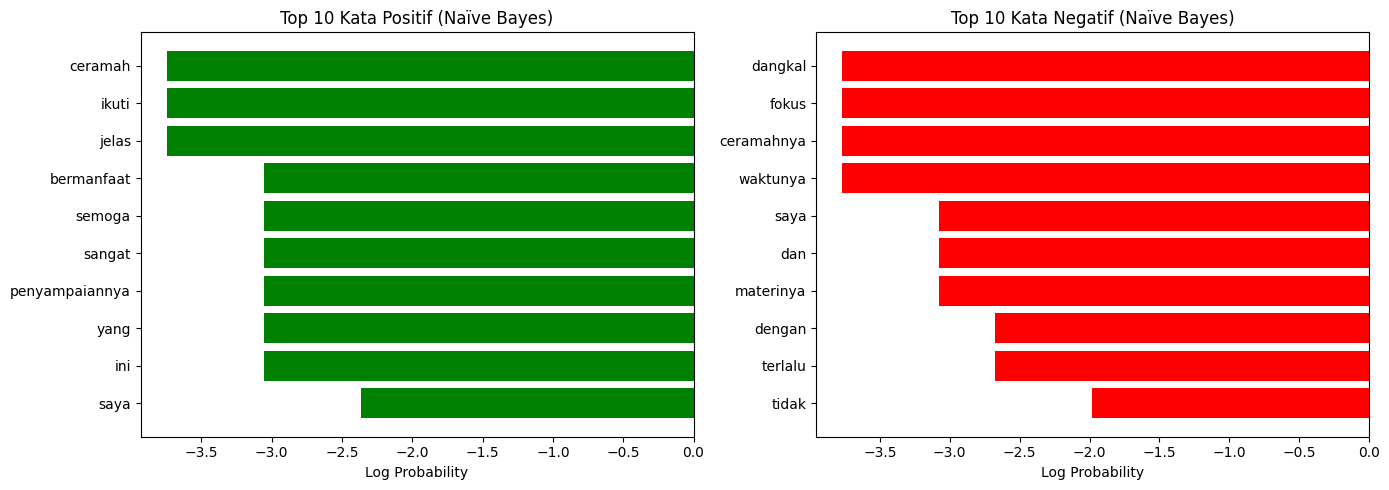

=== ANALISIS ERROR ===
Total error: 3 dari 4 data
Error rate: 75.00%

Contoh kesalahan prediksi:
  Komentar: ...
  Aktual: negatif, Prediksi: positif
  Komentar: ...
  Aktual: negatif, Prediksi: positif
  Komentar: ...
  Aktual: positif, Prediksi: negatif
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [ ]:
#PRAKTIKUM (umtuk tugas ada di cell dibawah ini)
# Buat folder proyek
!mkdir pertemuan5-svm-naivebayes
%cd pertemuan5-svm-naivebayes

# Inisialisasi git
!git init
!git config --global user.email "244110601105@mhs.uinsaizu.ac.id"
!git config --global user.name "244110601105-Adinda"

# Buat file README
!echo "# Praktikum SVM & Naive Bayes" > README.md
!git add README.md
!git commit -m "Initial commit: README"

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Clone repository
%cd /content/drive/MyDrive
!git clone https://github.com/244110601105-Adinda/pertemuan5-svm-naivebayes.git
%cd pertemuan5-svm-naivebayes

# Cek status
!git status

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 6)
print("Library berhasil diimport!")


# Dataset teks sederhana: komentar terhadap konten dakwah
data = {
    'komentar': [
        "Alhamdulillah, ceramahnya sangat bermanfaat",
        "Materi ini mencerahkan hati saya",
        "Terima kasih ustadz, ilmunya sangat berguna",
        "Saya suka cara penyampaiannya yang santun",
        "Semoga Allah membalas kebaikan ustadz",
        "Ini ceramah terbaik yang pernah saya dengar",
        "Materinya dalam dan mudah dipahami",
        "Sangat menginspirasi, semoga istiqomah",
        "Kajiannya rutin saya ikuti, selalu bermanfaat",
        "Penyampaiannya jelas dan tidak membosankan",
        "Ceramahnya terlalu panjang dan membosankan",
        "Materinya tidak sesuai dengan tema",
        "Saya tidak paham dengan penjelasannya",
        "Suaranya kurang jelas, sulit didengar",
        "Terlalu banyak basa-basi, tidak fokus",
        "Kontennya tidak relevan dengan kebutuhan saya",
        "Saya kecewa dengan penyampaiannya",
        "Materinya dangkal dan tidak mendalam",
        "Waktunya terlalu lama, membuat ngantuk",
        "Tidak ada contoh praktis, hanya teori"
    ],
    'sentimen': [
        'positif', 'positif', 'positif', 'positif', 'positif',
        'positif', 'positif', 'positif', 'positif', 'positif',
        'negatif', 'negatif', 'negatif', 'negatif', 'negatif',
        'negatif', 'negatif', 'negatif', 'negatif', 'negatif'
    ]
}
df = pd.DataFrame(data)
print("Jumlah data:", len(df))
print(df.head(10))
print("\nDistribusi kelas:\n", df['sentimen'].value_counts())


# ==================== NAÏVE BAYES FROM SCRATCH ====================

class NaiveBayesScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing
        self.classes = None
        self.prior = {}
        self.likelihood = {}
        self.vocab = None

    def fit(self, X, y):
        """
        X: matriks count/fitur (n_samples, n_features)
        y: label (n_samples,)
        """
        self.classes = np.unique(y)
        n_samples, n_features = X.shape

        # Hitung prior
        for c in self.classes:
            self.prior[c] = np.sum(y == c) / n_samples

        # Hitung likelihood per fitur
        for c in self.classes:
            X_c = X[y == c]
            # P(x_i = 1 | c) dengan Laplace smoothing
            count_1 = np.sum(X_c, axis=0)
            prob_1 = (count_1 + self.alpha) / (len(X_c) + 2 * self.alpha)
            self.likelihood[c] = prob_1

    def predict(self, X):
        predictions = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                # Log posterior untuk menghindari underflow
                log_posterior = np.log(self.prior[c])
                for i, xi in enumerate(x):
                    p = self.likelihood[c][i]
                    if xi > 0:
                        log_posterior += xi * np.log(p)
                posteriors[c] = log_posterior
            predictions.append(max(posteriors, key=posteriors.get))
        return np.array(predictions)

    def predict_proba(self, X):
        """Return probabilitas posterior (softmax dari log posterior)."""
        probas = []
        for x in X:
            log_posteriors = {}
            for c in self.classes:
                log_posterior = np.log(self.prior[c])
                for i, xi in enumerate(x):
                    p = self.likelihood[c][i]
                    if xi > 0:
                        log_posterior += xi * np.log(p)
                log_posteriors[c] = log_posterior

            # Softmax
            max_log = max(log_posteriors.values())
            exp_vals = {c: np.exp(lp - max_log) for c, lp in log_posteriors.items()}
            total = sum(exp_vals.values())
            probas.append([exp_vals[c]/total for c in self.classes])
        return np.array(probas)

# ==================== UJI NAÏVE BAYES FROM SCRATCH ====================

# Vectorize teks dengan CountVectorizer
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(df['komentar']).toarray()
y = df['sentimen'].values

print(f"Jumlah fitur (kata unik): {X_counts.shape[1]}")
print(f"Contoh vocabulary: {list(vectorizer.vocabulary_.keys())[:10]}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_counts, y, test_size=0.2, random_state=42, stratify=y
)

# Training Naïve Bayes from scratch
nb_scratch = NaiveBayesScratch(alpha=1.0)
nb_scratch.fit(X_train, y_train)
y_pred_nb_scratch = nb_scratch.predict(X_test)

print("\n=== NAÏVE BAYES FROM SCRATCH ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb_scratch):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_nb_scratch, pos_label='positif'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_scratch))


# ==================== SVM DENGAN SCIKIT-LEARN ====================

# SVM Linear
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_svm_linear = svm_linear.predict(X_test)

# SVM RBF
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test)

print("=== SVM LINEAR ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_linear):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_svm_linear, pos_label='positif'):.4f}")

print("\n=== SVM RBF ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_rbf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_svm_rbf, pos_label='positif'):.4f}")


# ==================== PERBANDINGAN LENGKAP ====================

# Naïve Bayes scikit-learn (MultinomialNB)
nb_sk = MultinomialNB(alpha=1.0)
nb_sk.fit(X_train, y_train)
y_pred_nb_sk = nb_sk.predict(X_test)

# Naïve Bayes Bernoulli
nb_bernoulli = BernoulliNB(alpha=1.0)
nb_bernoulli.fit(X_train, y_train)
y_pred_nb_bernoulli = nb_bernoulli.predict(X_test)

# Tabel perbandingan
results = pd.DataFrame({
    'Model': ['NB Scratch', 'NB Multinomial', 'NB Bernoulli', 'SVM Linear', 'SVM RBF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb_scratch),
        accuracy_score(y_test, y_pred_nb_sk),
        accuracy_score(y_test, y_pred_nb_bernoulli),
        accuracy_score(y_test, y_pred_svm_linear),
        accuracy_score(y_test, y_pred_svm_rbf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_nb_scratch, pos_label='positif'),
        f1_score(y_test, y_pred_nb_sk, pos_label='positif'),
        f1_score(y_test, y_pred_nb_bernoulli, pos_label='positif'),
        f1_score(y_test, y_pred_svm_linear, pos_label='positif'),
        f1_score(y_test, y_pred_svm_rbf, pos_label='positif')
    ]
})
print("=== PERBANDINGAN MODEL ===")
print(results.to_string(index=False))


# ==================== CONFUSION MATRIX ====================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('NB Scratch', y_pred_nb_scratch),
    ('NB Multinomial', y_pred_nb_sk),
    ('SVM Linear', y_pred_svm_linear)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred, labels=['negatif', 'positif'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['negatif', 'positif'])
    ax.set_yticklabels(['negatif', 'positif'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


# ==================== CROSS-VALIDATION ====================

models_cv = {
    'NB Multinomial': MultinomialNB(alpha=1.0),
    'NB Bernoulli': BernoulliNB(alpha=1.0),
    'SVM Linear': SVC(kernel='linear', C=1.0, random_state=42),
    'SVM RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
}

print("=== CROSS-VALIDATION (5-Fold) ===")
for name, model in models_cv.items():
    scores = cross_val_score(model, X_counts, y, cv=5, scoring='f1_weighted')
    print(f"{name:20s} | F1: {scores.mean():.4f} ± {scores.std():.4f}")


# ==================== GRIDSEARCH SVM ====================

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("=== GRIDSEARCH SVM ===")
print(f"Best Parameters: {grid_svm.best_params_}")
print(f"Best CV Score  : {grid_svm.best_score_:.4f}")

# Evaluasi pada test set
y_pred_svm_best = grid_svm.best_estimator_.predict(X_test)
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred_svm_best):.4f}")
print(f"Test F1-Score  : {f1_score(y_test, y_pred_svm_best, pos_label='positif'):.4f}")


# ==================== GRIDSEARCH NAÏVE BAYES ====================

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print("=== GRIDSEARCH NAÏVE BAYES ===")
print(f"Best Alpha: {grid_nb.best_params_}")
print(f"Best CV Score: {grid_nb.best_score_:.4f}")

y_pred_nb_best = grid_nb.best_estimator_.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_nb_best):.4f}")


# ==================== PREDIKSI DATA BARU ====================

# Data komentar baru
komentar_baru = [
    "Alhamdulillah, kajiannya sangat bermanfaat dan menenangkan hati",
    "Saya kecewa, materinya tidak sesuai dan membosankan",
    "Penyampaian ustadz sangat jelas dan mudah dipahami"
]

# Vectorize
X_new = vectorizer.transform(komentar_baru).toarray()

# Prediksi dengan model terbaik
pred_nb = grid_nb.best_estimator_.predict(X_new)
pred_svm = grid_svm.best_estimator_.predict(X_new)

print("=== PREDIKSI DATA BARU ===")
for komentar, nb, svm in zip(komentar_baru, pred_nb, pred_svm):
    print(f"\nKomentar: '{komentar}'")
    print(f"  Naïve Bayes: {nb.upper()}")
    print(f"  SVM        : {svm.upper()}")


# ==================== FEATURE IMPORTANCE NAÏVE BAYES ====================

# Log probabilities untuk kelas positif dan negatif
feature_names = vectorizer.get_feature_names_out()
log_prob_pos = grid_nb.best_estimator_.feature_log_prob_[1]  # positif
log_prob_neg = grid_nb.best_estimator_.feature_log_prob_[0]  # negatif

# Kata yang paling mengindikasikan positif/negatif
top_pos = np.argsort(log_prob_pos)[-10:][::-1]
top_neg = np.argsort(log_prob_neg)[-10:][::-1]

print("=== KATA PALING INDIKATIF POSITIF ===")
for idx in top_pos:
    print(f"  {feature_names[idx]}: {log_prob_pos[idx]:.4f}")

print("\n=== KATA PALING INDIKATIF NEGATIF ===")
for idx in top_neg:
    print(f"  {feature_names[idx]}: {log_prob_neg[idx]:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_pos], [log_prob_pos[i] for i in top_pos], color='green')
axes[0].set_title('Top 10 Kata Positif (Naïve Bayes)')
axes[0].set_xlabel('Log Probability')

axes[1].barh([feature_names[i] for i in top_neg], [log_prob_neg[i] for i in top_neg], color='red')
axes[1].set_title('Top 10 Kata Negatif (Naïve Bayes)')
axes[1].set_xlabel('Log Probability')

plt.tight_layout()
plt.show()


# ==================== ANALISIS ERROR ====================

# Prediksi pada data test dengan model terbaik
y_pred_final = grid_svm.best_estimator_.predict(X_test)

# Identifikasi kesalahan
errors = y_test != y_pred_final
error_indices = np.where(errors)[0]

print("=== ANALISIS ERROR ===")
print(f"Total error: {len(error_indices)} dari {len(y_test)} data")
print(f"Error rate: {len(error_indices)/len(y_test)*100:.2f}%")

# Tampilkan contoh kesalahan
if len(error_indices) > 0:
    print("\nContoh kesalahan prediksi:")
    for idx in error_indices[:5]:
        print(f"  Komentar: ...")
        print(f"  Aktual: {y_test[idx]}, Prediksi: {y_pred_final[idx]}")


# ==================== COMMIT & PUSH ====================

# Simpan notebook terlebih dahulu (File → Save)
# Lalu di terminal Colab:

!git add .
!git commit -m "Praktikum SVM & Naïve Bayes: implementasi from scratch + tuning"
!git push origin main

Library berhasil di-import!

================ DATASET ================
Jumlah data: 60
label
positive    20
negative    20
neutral     20
Name: count, dtype: int64

================ CEK DATA ================
text     0
label    0
dtype: int64


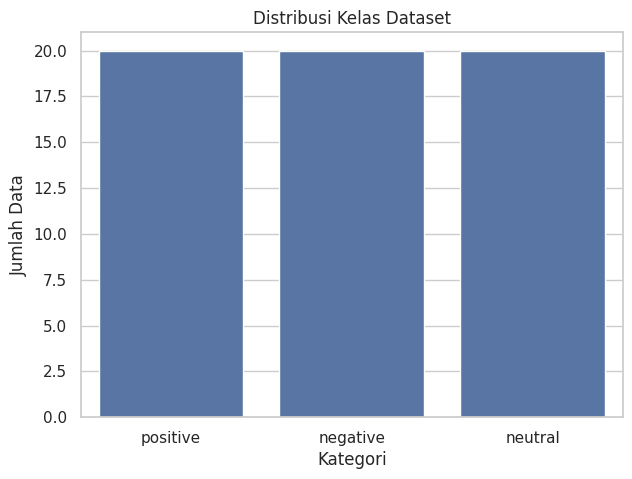

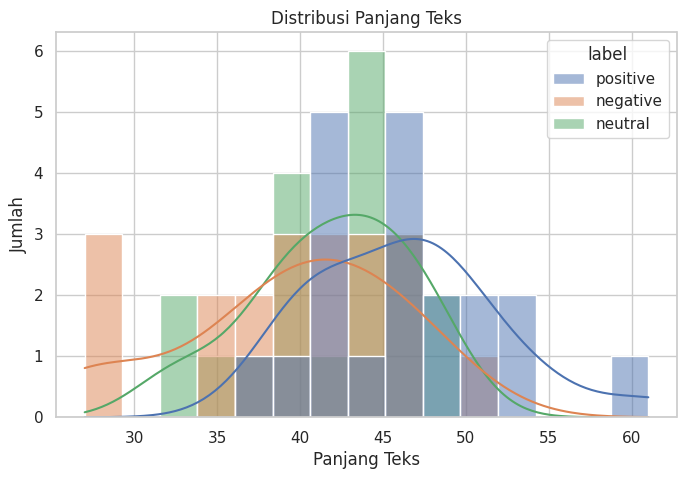

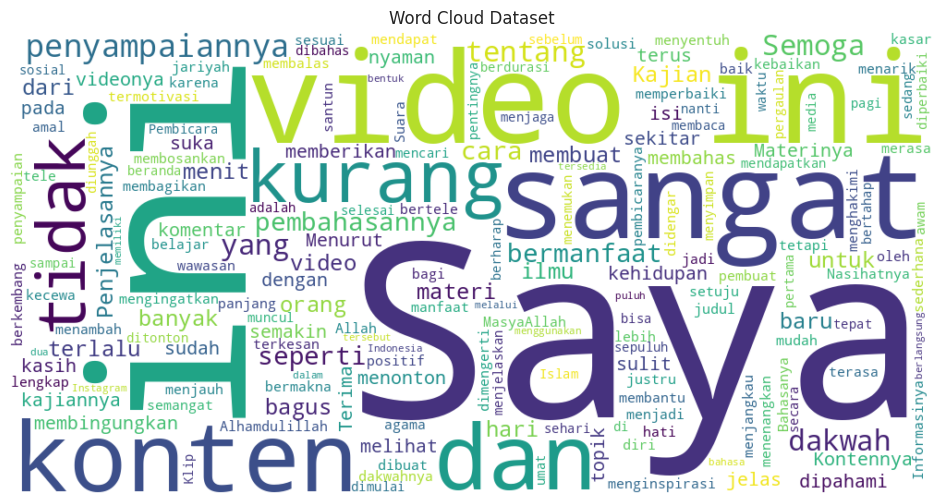


================ HASIL PREPROCESSING ================
SEBELUM : Dakwah ini sangat bermanfaat dan mudah dipahami
SESUDAH : dakwah sangat manfaat mudah paham
------------------------------------------------------------
SEBELUM : MasyaAllah kajiannya sangat menginspirasi
SESUDAH : masyaallah kaji sangat inspirasi
------------------------------------------------------------
SEBELUM : Penjelasannya bagus dan menenangkan hati
SESUDAH : jelas bagus tenang hati
------------------------------------------------------------
SEBELUM : Semoga konten seperti ini terus dibuat
SESUDAH : moga konten terus buat
------------------------------------------------------------
SEBELUM : Terima kasih sudah membagikan ilmu yang bermanfaat
SESUDAH : terima kasih bagi ilmu manfaat
------------------------------------------------------------

================ TRAIN TEST SPLIT ================
Data training : 48
Data testing  : 12

CountVectorizer:
Training: (48, 113)
Testing : (12, 113)

TF-IDF:
Training: (48, 11

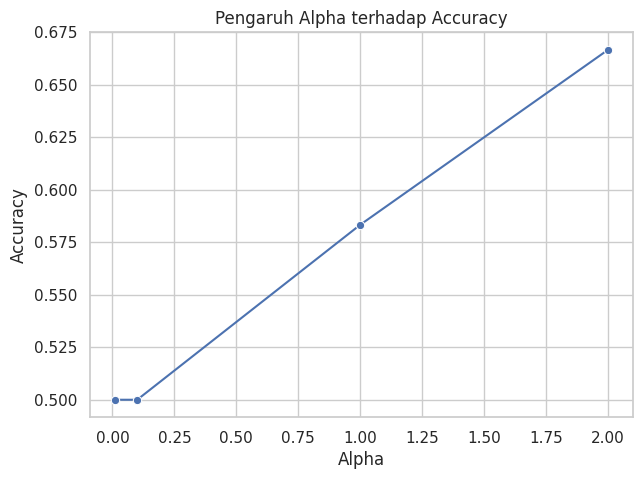


================ MULTINOMIAL NB ================
              precision    recall  f1-score   support

    negative       0.50      0.50      0.50         4
     neutral       0.67      0.50      0.57         4
    positive       0.60      0.75      0.67         4

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12


================ BERNOULLI NB ================
              precision    recall  f1-score   support

    negative       0.40      0.50      0.44         4
     neutral       0.60      0.75      0.67         4
    positive       0.50      0.25      0.33         4

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.48        12
weighted avg       0.50      0.50      0.48        12


================ SVM LINEAR ================
              precision    recall  f1-score   support

    negative       0.50      0.50      

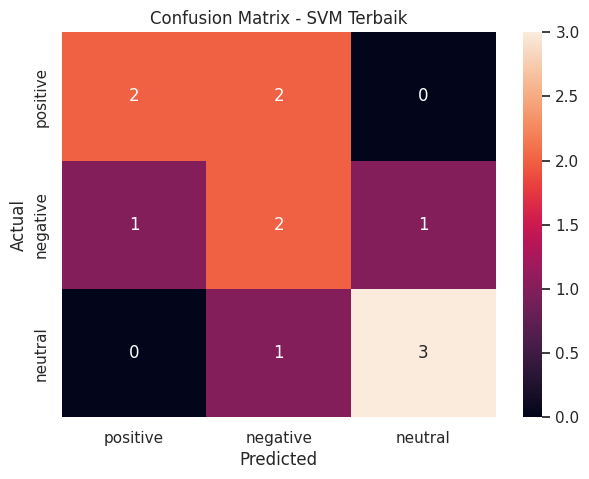

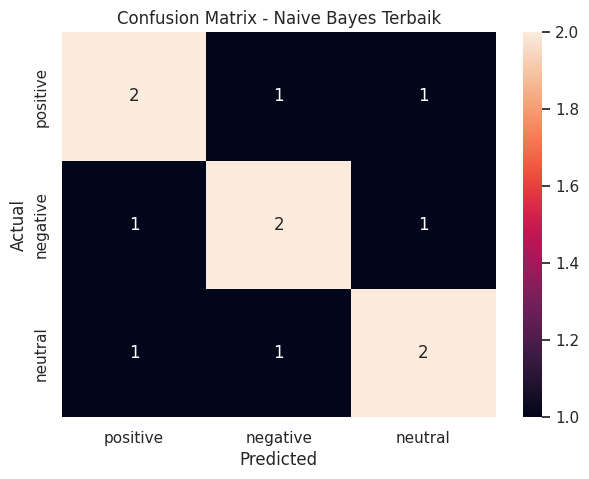


================ 5-FOLD CROSS VALIDATION ================
SVM:
[0.47619048 0.69357143 1.         0.64285714 0.77777778]
Mean: 0.7180793650793651

Naive Bayes:
[0.58571429 0.69357143 1.         0.64285714 0.78333333]
Mean: 0.741095238095238

================ HASIL EVALUASI FINAL ================
              Model  Accuracy  Precision   Recall       F1  CV F1 Mean
Naive Bayes Terbaik  0.500000   0.500000 0.500000 0.500000    0.741095
        SVM Terbaik  0.583333   0.605556 0.583333 0.588624    0.718079

================ TOP 10 KATA SETIAP KELAS ================

Kelas: negative
kurang -> -2.4998
konten -> -2.8971
sampai -> -2.8971
terlalu -> -3.1767
jelas -> -3.1767
nyaman -> -3.5662
tele -> -3.5662
sulit -> -3.5662
video -> -3.5662
isi -> -3.5662

Kelas: neutral
video -> -2.348
bahas -> -2.8971
materi -> -2.8971
tonton -> -3.1767
menit -> -3.1767
komentar -> -3.5662
topik -> -3.5662
puluh -> -3.5662
kaji -> -3.5662
selesai -> -4.2128

Kelas: positive
sangat -> -2.4113
moga -> -3.092

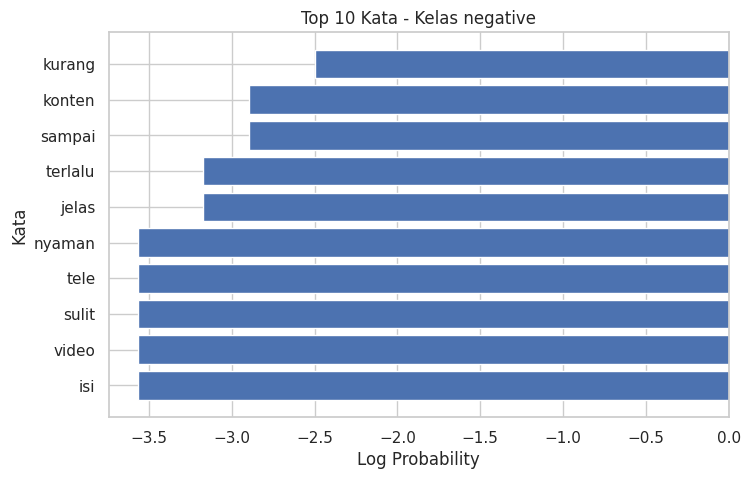

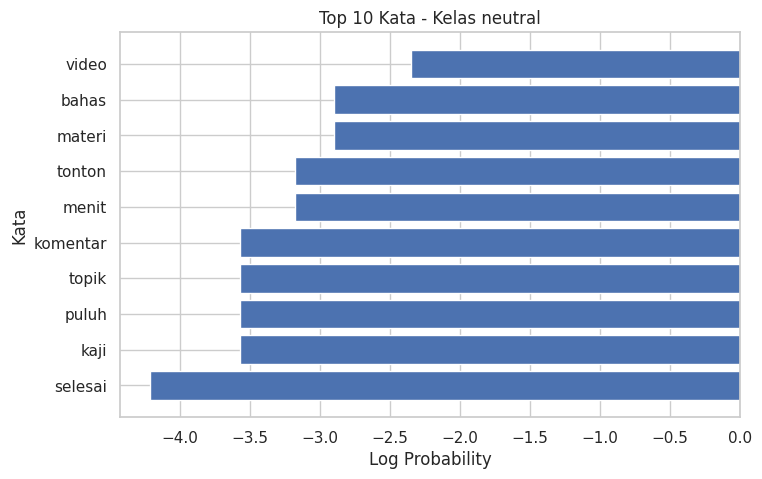

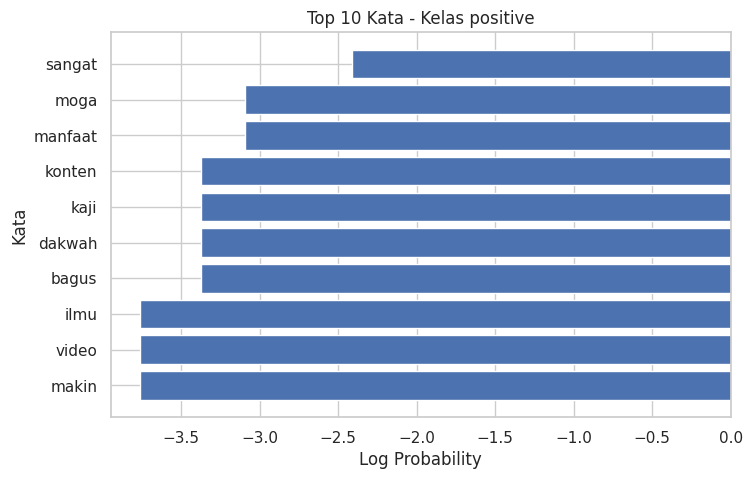


================ ERROR ANALYSIS ================
Jumlah kesalahan: 5

Teks     : temu konten media sosial
Aktual   : neutral
Prediksi : negative
----------------------------------------------------------------------
Teks     : video asa bosan
Aktual   : negative
Prediksi : neutral
----------------------------------------------------------------------
Teks     : suka cara sampai santun
Aktual   : positive
Prediksi : negative
----------------------------------------------------------------------
Teks     : dakwah justru buat orang jauh
Aktual   : negative
Prediksi : positive
----------------------------------------------------------------------
Teks     : materi sangat jelas bingung
Aktual   : positive
Prediksi : negative
----------------------------------------------------------------------

================ PREDIKSI KOMENTAR BARU ================
Komentar : MasyaAllah kajian ini sangat bermanfaat
Prediksi  : positive
------------------------------------------------------------
Komenta

In [12]:
# ============================================================
# PRAKTIKUM SVM & NAIVE BAYES
# Klasifikasi Komentar Media Sosial Dakwah
# ============================================================

# =========================
# 1. INSTALL & IMPORT
# =========================

!pip install -q Sastrawi wordcloud seaborn

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Library berhasil di-import!")


# =========================
# 2. DATASET
# =========================

data = [

    # POSITIVE
    ("Dakwah ini sangat bermanfaat dan mudah dipahami", "positive"),
    ("MasyaAllah kajiannya sangat menginspirasi", "positive"),
    ("Penjelasannya bagus dan menenangkan hati", "positive"),
    ("Semoga konten seperti ini terus dibuat", "positive"),
    ("Terima kasih sudah membagikan ilmu yang bermanfaat", "positive"),
    ("Kajian ini membuat saya semakin semangat belajar agama", "positive"),
    ("Materinya sangat jelas dan tidak membingungkan", "positive"),
    ("Sangat bagus, semoga menjadi amal jariyah", "positive"),
    ("Saya suka cara penyampaiannya yang santun", "positive"),
    ("Konten dakwah seperti ini sangat membantu", "positive"),
    ("Semoga Allah membalas kebaikan pembuat konten ini", "positive"),
    ("Nasihatnya sangat menyentuh dan bermanfaat", "positive"),
    ("Alhamdulillah mendapat ilmu baru dari video ini", "positive"),
    ("Penyampaiannya sederhana tetapi sangat bermakna", "positive"),
    ("Semoga semakin banyak konten positif seperti ini", "positive"),
    ("Kajian yang sangat bagus untuk menambah wawasan", "positive"),
    ("Saya jadi lebih termotivasi untuk memperbaiki diri", "positive"),
    ("Terima kasih sudah mengingatkan dengan cara yang baik", "positive"),
    ("Video ini sangat memberikan manfaat bagi saya", "positive"),
    ("Semoga dakwahnya terus berkembang dan menjangkau banyak orang", "positive"),

    # NEGATIVE
    ("Saya tidak suka cara penyampaian dakwah ini", "negative"),
    ("Penjelasannya terlalu membingungkan", "negative"),
    ("Kontennya kurang jelas dan sulit dipahami", "negative"),
    ("Saya kecewa karena isi videonya tidak sesuai judul", "negative"),
    ("Penyampaiannya terlalu kasar", "negative"),
    ("Menurut saya pembahasannya tidak menarik", "negative"),
    ("Video ini terasa membosankan", "negative"),
    ("Informasinya kurang lengkap", "negative"),
    ("Saya kurang setuju dengan cara penyampaiannya", "negative"),
    ("Suara pembicaranya kurang nyaman didengar", "negative"),
    ("Dakwah seperti ini justru membuat orang menjauh", "negative"),
    ("Penjelasannya terlalu panjang dan bertele-tele", "negative"),
    ("Saya merasa konten ini kurang bermanfaat", "negative"),
    ("Bahasanya sulit dimengerti oleh orang awam", "negative"),
    ("Penyampaiannya terkesan menghakimi", "negative"),
    ("Isi kontennya tidak memberikan solusi", "negative"),
    ("Saya tidak mendapatkan ilmu baru dari video ini", "negative"),
    ("Menurut saya pembahasannya kurang tepat", "negative"),
    ("Konten ini membuat saya kurang nyaman", "negative"),
    ("Saya berharap penyampaiannya bisa diperbaiki", "negative"),

    # NEUTRAL
    ("Saya baru melihat video dakwah ini hari ini", "neutral"),
    ("Video ini membahas tentang kehidupan sehari-hari", "neutral"),
    ("Kajiannya dimulai pada menit pertama", "neutral"),
    ("Saya sedang mencari materi tentang topik ini", "neutral"),
    ("Video ini muncul di beranda saya", "neutral"),
    ("Pembahasannya tentang pentingnya menjaga waktu", "neutral"),
    ("Saya menyimpan video ini untuk ditonton nanti", "neutral"),
    ("Klip ini berdurasi sekitar sepuluh menit", "neutral"),
    ("Saya membaca komentar sebelum menonton videonya", "neutral"),
    ("Materinya membahas tentang kehidupan umat Islam", "neutral"),
    ("Video ini diunggah pada pagi hari", "neutral"),
    ("Saya menemukan konten ini dari media sosial", "neutral"),
    ("Pembicara menjelaskan materi secara bertahap", "neutral"),
    ("Topik yang dibahas adalah tentang pergaulan", "neutral"),
    ("Saya menonton video ini sampai selesai", "neutral"),
    ("Konten ini menggunakan bahasa Indonesia", "neutral"),
    ("Video tersebut memiliki banyak komentar", "neutral"),
    ("Saya melihat video ini melalui Instagram", "neutral"),
    ("Materi kajian tersedia dalam bentuk video", "neutral"),
    ("Pembahasannya berlangsung sekitar dua puluh menit", "neutral"),
]

df = pd.DataFrame(data, columns=["text", "label"])

print("\n================ DATASET ================")
print("Jumlah data:", len(df))
print(df["label"].value_counts())


# =========================
# 3. EDA
# =========================

print("\n================ CEK DATA ================")
print(df.isnull().sum())

plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="label",
    order=["positive", "negative", "neutral"]
)
plt.title("Distribusi Kelas Dataset")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.show()

df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=15,
    kde=True
)
plt.title("Distribusi Panjang Teks")
plt.xlabel("Panjang Teks")
plt.ylabel("Jumlah")
plt.show()

all_text = " ".join(df["text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Dataset")
plt.show()


# =========================
# 4. PREPROCESSING
# =========================

stopword_factory = StopWordRemoverFactory()
stopwords = set(stopword_factory.get_stop_words())

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()


def preprocessing(text):

    # Case folding
    text = text.lower()

    # Hapus URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # Hapus angka
    text = re.sub(r"\d+", "", text)

    # Hapus tanda baca
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenisasi
    tokens = text.split()

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stopwords
    ]

    # Stemming
    text = " ".join(tokens)
    text = stemmer.stem(text)

    return text


df["clean_text"] = df["text"].apply(preprocessing)

print("\n================ HASIL PREPROCESSING ================")

for i in range(5):
    print("SEBELUM :", df.loc[i, "text"])
    print("SESUDAH :", df.loc[i, "clean_text"])
    print("-" * 60)


# =========================
# 5. TRAIN TEST SPLIT
# =========================

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n================ TRAIN TEST SPLIT ================")
print("Data training :", len(X_train))
print("Data testing  :", len(X_test))


# =========================
# 6. COUNT VECTORIZER
# =========================

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("\nCountVectorizer:")
print("Training:", X_train_count.shape)
print("Testing :", X_test_count.shape)


# =========================
# 7. TF-IDF
# =========================

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF:")
print("Training:", X_train_tfidf.shape)
print("Testing :", X_test_tfidf.shape)


# =========================
# 8. NAIVE BAYES FROM SCRATCH
# =========================

class MultinomialNBScratch:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)

        self.class_log_prior_ = {}
        self.feature_log_prob_ = {}

        n_samples, n_features = X.shape

        for c in self.classes_:

            X_c = X[y == c]

            # Prior probability
            self.class_log_prior_[c] = np.log(
                X_c.shape[0] / n_samples
            )

            # Jumlah kata setiap fitur
            feature_count = X_c.sum(axis=0)

            # Laplace smoothing
            smoothed_count = feature_count + self.alpha

            smoothed_total = (
                feature_count.sum()
                + self.alpha * n_features
            )

            self.feature_log_prob_[c] = np.log(
                smoothed_count / smoothed_total
            )

        return self

    def predict(self, X):

        X = np.asarray(X)

        predictions = []

        for row in X:

            class_scores = {}

            for c in self.classes_:

                score = self.class_log_prior_[c]

                score += np.sum(
                    row * self.feature_log_prob_[c]
                )

                class_scores[c] = score

            predictions.append(
                max(
                    class_scores,
                    key=class_scores.get
                )
            )

        return np.array(predictions)


X_train_count_dense = X_train_count.toarray()
X_test_count_dense = X_test_count.toarray()


# =========================
# 9. ALPHA COMPARISON
# =========================

alphas = [0.01, 0.1, 1.0, 2.0]

alpha_results = []

for alpha in alphas:

    model = MultinomialNBScratch(
        alpha=alpha
    )

    model.fit(
        X_train_count_dense,
        y_train.values
    )

    prediction = model.predict(
        X_test_count_dense
    )

    acc = accuracy_score(
        y_test,
        prediction
    )

    alpha_results.append({
        "Alpha": alpha,
        "Accuracy": acc
    })

alpha_df = pd.DataFrame(alpha_results)

print("\n================ NAIVE BAYES FROM SCRATCH ================")
print(alpha_df)

plt.figure(figsize=(7,5))

sns.lineplot(
    data=alpha_df,
    x="Alpha",
    y="Accuracy",
    marker="o"
)

plt.title("Pengaruh Alpha terhadap Accuracy")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.show()


# =========================
# 10. MULTINOMIAL NB
# =========================

mnb = MultinomialNB()

mnb.fit(
    X_train_count,
    y_train
)

pred_mnb = mnb.predict(
    X_test_count
)

print("\n================ MULTINOMIAL NB ================")
print(
    classification_report(
        y_test,
        pred_mnb,
        zero_division=0
    )
)


# =========================
# 11. BERNOULLI NB
# =========================

bnb = BernoulliNB()

bnb.fit(
    X_train_count,
    y_train
)

pred_bnb = bnb.predict(
    X_test_count
)

print("\n================ BERNOULLI NB ================")
print(
    classification_report(
        y_test,
        pred_bnb,
        zero_division=0
    )
)


# =========================
# 12. SVM LINEAR
# =========================

svm_linear = SVC(
    kernel="linear"
)

svm_linear.fit(
    X_train_tfidf,
    y_train
)

pred_svm_linear = svm_linear.predict(
    X_test_tfidf
)

print("\n================ SVM LINEAR ================")
print(
    classification_report(
        y_test,
        pred_svm_linear,
        zero_division=0
    )
)


# =========================
# 13. SVM RBF
# =========================

svm_rbf = SVC(
    kernel="rbf"
)

svm_rbf.fit(
    X_train_tfidf,
    y_train
)

pred_svm_rbf = svm_rbf.predict(
    X_test_tfidf
)

print("\n================ SVM RBF ================")
print(
    classification_report(
        y_test,
        pred_svm_rbf,
        zero_division=0
    )
)


# =========================
# 14. SVM POLYNOMIAL
# =========================

svm_poly = SVC(
    kernel="poly"
)

svm_poly.fit(
    X_train_tfidf,
    y_train
)

pred_svm_poly = svm_poly.predict(
    X_test_tfidf
)

print("\n================ SVM POLYNOMIAL ================")
print(
    classification_report(
        y_test,
        pred_svm_poly,
        zero_division=0
    )
)


# =========================
# 15. PERBANDINGAN MODEL
# =========================

models = {
    "Multinomial NB": pred_mnb,
    "Bernoulli NB": pred_bnb,
    "SVM Linear": pred_svm_linear,
    "SVM RBF": pred_svm_rbf,
    "SVM Polynomial": pred_svm_poly
}

comparison = []

for name, prediction in models.items():

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Precision": precision_score(
            y_test,
            prediction,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            prediction,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            prediction,
            average="weighted",
            zero_division=0
        )
    })

comparison_df = pd.DataFrame(
    comparison
)

print("\n================ PERBANDINGAN MODEL ================")
print(
    comparison_df.sort_values(
        "Accuracy",
        ascending=False
    ).to_string(index=False)
)


# =========================
# 16. COUNT VS TF-IDF
# =========================

vectorizer_results = []


# Multinomial NB + Count
model_count_nb = MultinomialNB()

model_count_nb.fit(
    X_train_count,
    y_train
)

pred = model_count_nb.predict(
    X_test_count
)

vectorizer_results.append({
    "Vectorizer": "CountVectorizer",
    "Model": "Multinomial NB",
    "Accuracy": accuracy_score(
        y_test,
        pred
    ),
    "F1": f1_score(
        y_test,
        pred,
        average="weighted"
    )
})


# Multinomial NB + TF-IDF
model_tfidf_nb = MultinomialNB()

model_tfidf_nb.fit(
    X_train_tfidf,
    y_train
)

pred = model_tfidf_nb.predict(
    X_test_tfidf
)

vectorizer_results.append({
    "Vectorizer": "TF-IDF",
    "Model": "Multinomial NB",
    "Accuracy": accuracy_score(
        y_test,
        pred
    ),
    "F1": f1_score(
        y_test,
        pred,
        average="weighted"
    )
})


# SVM + Count
model_count_svm = SVC(
    kernel="linear"
)

model_count_svm.fit(
    X_train_count,
    y_train
)

pred = model_count_svm.predict(
    X_test_count
)

vectorizer_results.append({
    "Vectorizer": "CountVectorizer",
    "Model": "SVM Linear",
    "Accuracy": accuracy_score(
        y_test,
        pred
    ),
    "F1": f1_score(
        y_test,
        pred,
        average="weighted"
    )
})


# SVM + TF-IDF
model_tfidf_svm = SVC(
    kernel="linear"
)

model_tfidf_svm.fit(
    X_train_tfidf,
    y_train
)

pred = model_tfidf_svm.predict(
    X_test_tfidf
)

vectorizer_results.append({
    "Vectorizer": "TF-IDF",
    "Model": "SVM Linear",
    "Accuracy": accuracy_score(
        y_test,
        pred
    ),
    "F1": f1_score(
        y_test,
        pred,
        average="weighted"
    )
})


vectorizer_df = pd.DataFrame(
    vectorizer_results
)

print("\n================ COUNT VS TF-IDF ================")
print(
    vectorizer_df.to_string(index=False)
)


# =========================
# 17. GRIDSEARCH SVM
# =========================

print("\n================ GRIDSEARCH SVM ================")

svm = SVC()

svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": [
        "linear",
        "rbf",
        "poly"
    ],
    "gamma": [
        "scale",
        "auto",
        0.01,
        0.1
    ]
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

svm_grid.fit(
    X_train_tfidf,
    y_train
)

print("Parameter terbaik:")
print(svm_grid.best_params_)

print("\nScore terbaik:")
print(svm_grid.best_score_)


# =========================
# 18. EVALUASI SVM TERBAIK
# =========================

best_svm = svm_grid.best_estimator_

pred_best_svm = best_svm.predict(
    X_test_tfidf
)

print("\n================ SVM TERBAIK ================")

print(
    classification_report(
        y_test,
        pred_best_svm,
        zero_division=0
    )
)


# =========================
# 19. GRIDSEARCH NAIVE BAYES
# =========================

print("\n================ GRIDSEARCH NAIVE BAYES ================")

nb = MultinomialNB()

nb_params = {
    "alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0
    ]
}

nb_grid = GridSearchCV(
    nb,
    nb_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

nb_grid.fit(
    X_train_count,
    y_train
)

print("Parameter terbaik:")
print(nb_grid.best_params_)

print("\nScore terbaik:")
print(nb_grid.best_score_)


# =========================
# 20. EVALUASI NB TERBAIK
# =========================

best_nb = nb_grid.best_estimator_

pred_best_nb = best_nb.predict(
    X_test_count
)

print("\n================ NAIVE BAYES TERBAIK ================")

print(
    classification_report(
        y_test,
        pred_best_nb,
        zero_division=0
    )
)


# =========================
# 21. CONFUSION MATRIX SVM
# =========================

cm = confusion_matrix(
    y_test,
    pred_best_svm,
    labels=[
        "positive",
        "negative",
        "neutral"
    ]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "positive",
        "negative",
        "neutral"
    ],
    yticklabels=[
        "positive",
        "negative",
        "neutral"
    ]
)

plt.title("Confusion Matrix - SVM Terbaik")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# 22. CONFUSION MATRIX NB
# =========================

cm_nb = confusion_matrix(
    y_test,
    pred_best_nb,
    labels=[
        "positive",
        "negative",
        "neutral"
    ]
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=[
        "positive",
        "negative",
        "neutral"
    ],
    yticklabels=[
        "positive",
        "negative",
        "neutral"
    ]
)

plt.title("Confusion Matrix - Naive Bayes Terbaik")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# 23. 5-FOLD CROSS VALIDATION
# =========================

print("\n================ 5-FOLD CROSS VALIDATION ================")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores_svm = cross_val_score(
    best_svm,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

cv_scores_nb = cross_val_score(
    best_nb,
    X_train_count,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("SVM:")
print(cv_scores_svm)
print("Mean:", cv_scores_svm.mean())

print("\nNaive Bayes:")
print(cv_scores_nb)
print("Mean:", cv_scores_nb.mean())


# =========================
# 24. EVALUASI FINAL
# =========================

final_results = pd.DataFrame([
    {
        "Model": "Naive Bayes Terbaik",
        "Accuracy": accuracy_score(
            y_test,
            pred_best_nb
        ),
        "Precision": precision_score(
            y_test,
            pred_best_nb,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred_best_nb,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred_best_nb,
            average="weighted",
            zero_division=0
        ),
        "CV F1 Mean": cv_scores_nb.mean()
    },

    {
        "Model": "SVM Terbaik",
        "Accuracy": accuracy_score(
            y_test,
            pred_best_svm
        ),
        "Precision": precision_score(
            y_test,
            pred_best_svm,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred_best_svm,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred_best_svm,
            average="weighted",
            zero_division=0
        ),
        "CV F1 Mean": cv_scores_svm.mean()
    }
])

print("\n================ HASIL EVALUASI FINAL ================")
print(
    final_results.to_string(index=False)
)


# =========================
# 25. FEATURE IMPORTANCE
# =========================

print("\n================ TOP 10 KATA SETIAP KELAS ================")

feature_names = np.array(
    count_vectorizer.get_feature_names_out()
)

classes = best_nb.classes_

for class_index, class_name in enumerate(classes):

    log_prob = best_nb.feature_log_prob_[
        class_index
    ]

    top_indices = np.argsort(
        log_prob
    )[-10:][::-1]

    print("\nKelas:", class_name)

    for index in top_indices:

        print(
            feature_names[index],
            "->",
            round(
                log_prob[index],
                4
            )
        )


# =========================
# 26. VISUALISASI TOP 10 KATA
# =========================

for class_index, class_name in enumerate(classes):

    log_prob = best_nb.feature_log_prob_[
        class_index
    ]

    top_indices = np.argsort(
        log_prob
    )[-10:][::-1]

    words = feature_names[
        top_indices
    ]

    scores = log_prob[
        top_indices
    ]

    plt.figure(figsize=(8,5))

    plt.barh(
        words[::-1],
        scores[::-1]
    )

    plt.title(
        f"Top 10 Kata - Kelas {class_name}"
    )

    plt.xlabel("Log Probability")
    plt.ylabel("Kata")

    plt.show()


# =========================
# 27. ERROR ANALYSIS
# =========================

error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": pred_best_svm
})

errors = error_df[
    error_df["actual"] !=
    error_df["predicted"]
]

print("\n================ ERROR ANALYSIS ================")

print(
    "Jumlah kesalahan:",
    len(errors)
)

if len(errors) > 0:

    print()

    for _, row in errors.iterrows():

        print("Teks     :", row["text"])
        print("Aktual   :", row["actual"])
        print("Prediksi :", row["predicted"])
        print("-" * 70)

else:

    print(
        "Tidak ada kesalahan prediksi "
        "pada data testing."
    )


# =========================
# 28. PREDIKSI KOMENTAR BARU
# =========================

print("\n================ PREDIKSI KOMENTAR BARU ================")

new_comments = [
    "MasyaAllah kajian ini sangat bermanfaat",
    "Saya tidak suka penyampaiannya terlalu kasar",
    "Saya baru menemukan video ini di Instagram"
]

new_clean = [
    preprocessing(text)
    for text in new_comments
]

new_vector = tfidf_vectorizer.transform(
    new_clean
)

new_prediction = best_svm.predict(
    new_vector
)

for text, prediction in zip(
    new_comments,
    new_prediction
):

    print("Komentar :", text)
    print("Prediksi  :", prediction)
    print("-" * 60)


# =========================
# 29. REFLEKSI ETIKA
# =========================

print("\n================ REFLEKSI ETIKA ================")

print("""
Model klasifikasi teks dapat membantu tim media pesantren
mengidentifikasi komentar positif, negatif, dan netral.
Namun, model tidak selalu memahami konteks bahasa secara sempurna.

Bias dapat muncul apabila dataset tidak seimbang, terlalu sedikit,
atau hanya mewakili gaya bahasa tertentu. Kesalahan klasifikasi
juga dapat menyebabkan komentar yang sebenarnya baik dianggap negatif,
atau sebaliknya.

Oleh karena itu, hasil model sebaiknya tidak digunakan sebagai satu-satunya
dasar untuk mengambil keputusan terhadap pengguna. Pemeriksaan manusia
tetap diperlukan terutama untuk komentar yang sensitif.

Prinsip adl (keadilan) dapat diterapkan dengan memastikan data dan proses
klasifikasi tidak merugikan kelompok tertentu. Prinsip maslahah dapat
diterapkan dengan menggunakan model untuk memberikan manfaat,
misalnya membantu pengelola media menemukan komentar yang membutuhkan
tindak lanjut tanpa mengabaikan pertimbangan manusia.
""")


# =========================
# 30. SIMPAN HASIL
# =========================

df.to_csv(
    "dataset_komentar_dakwah_preprocessed.csv",
    index=False
)

comparison_df.to_csv(
    "hasil_perbandingan_model.csv",
    index=False
)

final_results.to_csv(
    "hasil_evaluasi_final.csv",
    index=False
)

alpha_df.to_csv(
    "hasil_perbandingan_alpha.csv",
    index=False
)

vectorizer_df.to_csv(
    "hasil_count_vs_tfidf.csv",
    index=False
)